# SPRINT 2: Pré-Processamento e Feature Engineering

**Equipe:** Grupo 05

---

## SEÇÃO 1: REVISÃO E CARREGAMENTO

Nesta secção recapitulamos os principais problemas identificados na EDA da Sprint 1 e carregamos os dados **brutos** para iniciar o tratamento.

### Principais Desafios Mapeados na Sprint 1:
1. **Outliers Severos:** `price_usd` possui jogos gratuitos ($0.00) e títulos premium extremos (>$100), distorcendo a média.
2. **Valores Ausentes:** `metacritic_score` apresenta ~57% de nulos. Variáveis categóricas essenciais têm < 1% de nulos.
3. **Alta Cardinalidade:** `genres`, `developer`, `publisher` exigem estratégia cuidadosa de encoding ou engenharia de variáveis.
4. **Feature Engineering Necessário:** `release_date`, `positive_reviews` e `negative_reviews` precisam ser transformadas.

### Ações planejadas para esta Sprint:
- Diagnóstico explícito de missing values **antes e depois** de cada intervenção
- Auditoria de outliers em **todas** as variáveis numéricas (não apenas `price_usd`)
- Justificativa de encoding para cada variável categórica
- Criação de novas features com **demonstração visual de poder preditivo**
- Seleção formal de features (correlação + Feature Importance)
- Pipeline scikit-learn com divisão 60/20/20 sem data leakage

In [3]:
# ── Instalação das dependências (por garantia) ──────────────────────
import subprocess, sys

libs = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
]
for lib in libs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", lib])

# ── Imports ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection     import train_test_split
from sklearn.pipeline            import Pipeline
from sklearn.compose             import ColumnTransformer
from sklearn.impute              import SimpleImputer
from sklearn.preprocessing       import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble            import RandomForestRegressor

pd.set_option('display.max_columns', None)

# ── Carregamento ─────────────────────────────────────────────────────
print("--- 1. CARREGAMENTO DOS DADOS BRUTOS ---")

url_github = 'https://raw.githubusercontent.com/JoaoDysarz/steam-price-prediction/main/data/Sprint_01/steam_top_games_2026.csv'
df_raw = pd.read_csv(url_github)

print(f"Dataset bruto carregado")
print(f"➜ Inicial: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas\n")

df_processado = df_raw.copy()
df_processado.head()

--- 1. CARREGAMENTO DOS DADOS BRUTOS ---
Dataset bruto carregado
➜ Inicial: 1495 linhas x 29 colunas



,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,categories,tags,platforms_win,platforms_mac,platforms_linux,metacritic_score,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,"Single-player, Multi-player, Co-op, Online Co-...","RPG, Open World, Survival, Co-op, Online Co-Op...",True,False,False,NaN,23986,20738,7717,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy","Single-player, Steam Trading Cards, Family Sha...","RPG, Strategy, Turn-Based, Classic, Horror, Po...",True,True,True,NaN,909,1616,411,"200,000 .. 500,000",301,0,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie","Single-player, Steam Achievements, Steam Tradi...","Indie, Adventure, Visual Novel",True,True,False,NaN,0,79,35,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation","Single-player, Family Sharing","Simulation, Casual, RPG, Indie, Word Game, Idler",True,False,False,NaN,1169,769,509,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation","Single-player, Steam Achievements, Steam Cloud...","Simulation, Casual, Indie, Trains, First-Perso...",True,False,False,68.0,1948,2154,466,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...


---

## SEÇÃO 2: TRATAMENTO DE DADOS AUSENTES

**Objetivo:** Garantir que o dataset não possua valores em branco (NaN) que comprometam o algoritmo, aplicando estratégias adequadas e justificadas para cada coluna.

### Decisões e justificativas:
1. **Remoção de colunas sem poder preditivo:** `app_id`, `name`, `header_image`, `short_description`, `tags`, `categories`, `estimated_owners`, `release_date_formatada`.
2. **Nulos residuais em categóricas (< 1%):** `genres`, `developer`, `publisher`, `release_date` — remoção de poucas linhas não compromete o volume estatístico.
3. **`metacritic_score` (~57% nulos):** A coluna **não será removida** — a Sprint 1 demonstrou correlação com preços altos. Imputação via `SimpleImputer(strategy='median')` no Pipeline — mais robusta que a média para dados com distribuição assimétrica.
   - *Alternativa avaliada e descartada:* `KNNImputer` — com 57% de nulos, os vizinhos mais próximos também teriam dados ausentes, tornando a imputação estatisticamente instável e computacionalmente custosa.

In [4]:
print("--- 2. DIAGNÓSTICO DE MISSING VALUES (ANTES) ---")
nulos_antes = df_processado.isnull().sum()
pct_antes   = (nulos_antes / len(df_processado) * 100).round(2)
resumo_antes = pd.DataFrame({'Nulos': nulos_antes, '%': pct_antes})
resumo_antes = resumo_antes[resumo_antes['Nulos'] > 0].sort_values('%', ascending=False)
print(resumo_antes.to_string())

# ── Remoção de colunas sem poder preditivo ──────────────────────────
colunas_para_remover = [
    'app_id', 'name', 'header_image', 'short_description',
    'tags', 'categories', 'estimated_owners', 'release_date_formatada'
]
colunas_alvo = [c for c in colunas_para_remover if c in df_processado.columns]
df_processado = df_processado.drop(columns=colunas_alvo)
print(f"\nColunas removidas: {colunas_alvo}")

# ── Remoção de linhas com nulos em categóricas essenciais ───────────
colunas_cat_essenciais = ['genres', 'publisher', 'developer', 'release_date']
colunas_cat_existentes = [c for c in colunas_cat_essenciais if c in df_processado.columns]
antes_drop = len(df_processado)
df_processado = df_processado.dropna(subset=colunas_cat_existentes)
depois_drop = len(df_processado)
print(f"Linhas removidas (nulos residuais < 1%): {antes_drop - depois_drop}")

# ── Diagnóstico DEPOIS ──────────────────────────────────────────────
print("\n--- DIAGNÓSTICO DE MISSING VALUES (DEPOIS DA LIMPEZA INICIAL) ---")
nulos_depois = df_processado.isnull().sum()
pct_depois   = (nulos_depois / len(df_processado) * 100).round(2)
resumo_depois = pd.DataFrame({'Nulos': nulos_depois, '%': pct_depois})
resumo_depois = resumo_depois[resumo_depois['Nulos'] > 0].sort_values('%', ascending=False)
print(resumo_depois.to_string())
print("\nNota: 'metacritic_score' mantido intencionalmente — será imputado via Pipeline (mediana).")
print(f"\nShape após limpeza inicial: {df_processado.shape}")

--- 2. DIAGNÓSTICO DE MISSING VALUES (ANTES) ---
                   Nulos      %
metacritic_score     955  63.88
publisher             12   0.80
categories             9   0.60
developer              8   0.54
genres                 8   0.54
release_date           7   0.47
tags                   6   0.40
estimated_owners       5   0.33
short_description      2   0.13
header_image           1   0.07

Colunas removidas: ['app_id', 'name', 'header_image', 'short_description', 'tags', 'categories', 'estimated_owners']
Linhas removidas (nulos residuais < 1%): 30

--- DIAGNÓSTICO DE MISSING VALUES (DEPOIS DA LIMPEZA INICIAL) ---
                  Nulos      %
metacritic_score    936  63.89

Nota: 'metacritic_score' mantido intencionalmente — será imputado via Pipeline (mediana).

Shape após limpeza inicial: (1465, 22)


---

## SEÇÃO 3: TRATAMENTO DE OUTLIERS

**Objetivo:** Identificar e tratar valores extremos em **todas** as variáveis numéricas, com decisão documentada para cada uma.

### Estratégia:
- Identificação via **boxplot** (visual) + **cálculo explícito do IQR**
- Cada variável recebe decisão justificada: manter, remover, winsorizar ou transformar

--- 3. AUDITORIA DE OUTLIERS (IQR EXPLÍCITO) ---
Variáveis numéricas encontradas: ['price_usd', 'discount_pct', 'metacritic_score', 'recommendations', 'positive_reviews', 'negative_reviews', 'avg_playtime_forever', 'avg_playtime_2weeks', 'median_playtime', 'peak_ccu', 'required_age', 'dlc_count', 'achievements']

              Coluna      Q1       Q3     IQR  Lim Inf IQR  Lim Sup IQR  N Outliers  % Outliers
           price_usd    0.49    19.99    19.5       -28.76        49.24          51        3.48
        discount_pct    0.00     0.00     0.0         0.00         0.00         206       14.06
    metacritic_score   72.00    83.00    11.0        55.50        99.50          11        2.08
     recommendations  402.00 11405.00 11003.0    -16102.50     27909.50         180       12.29
    positive_reviews 1640.00 12725.00 11085.0    -14987.50     29352.50         175       11.95
    negative_reviews  321.00  2020.00  1699.0     -2227.50      4568.50         168       11.47
avg_playtime_

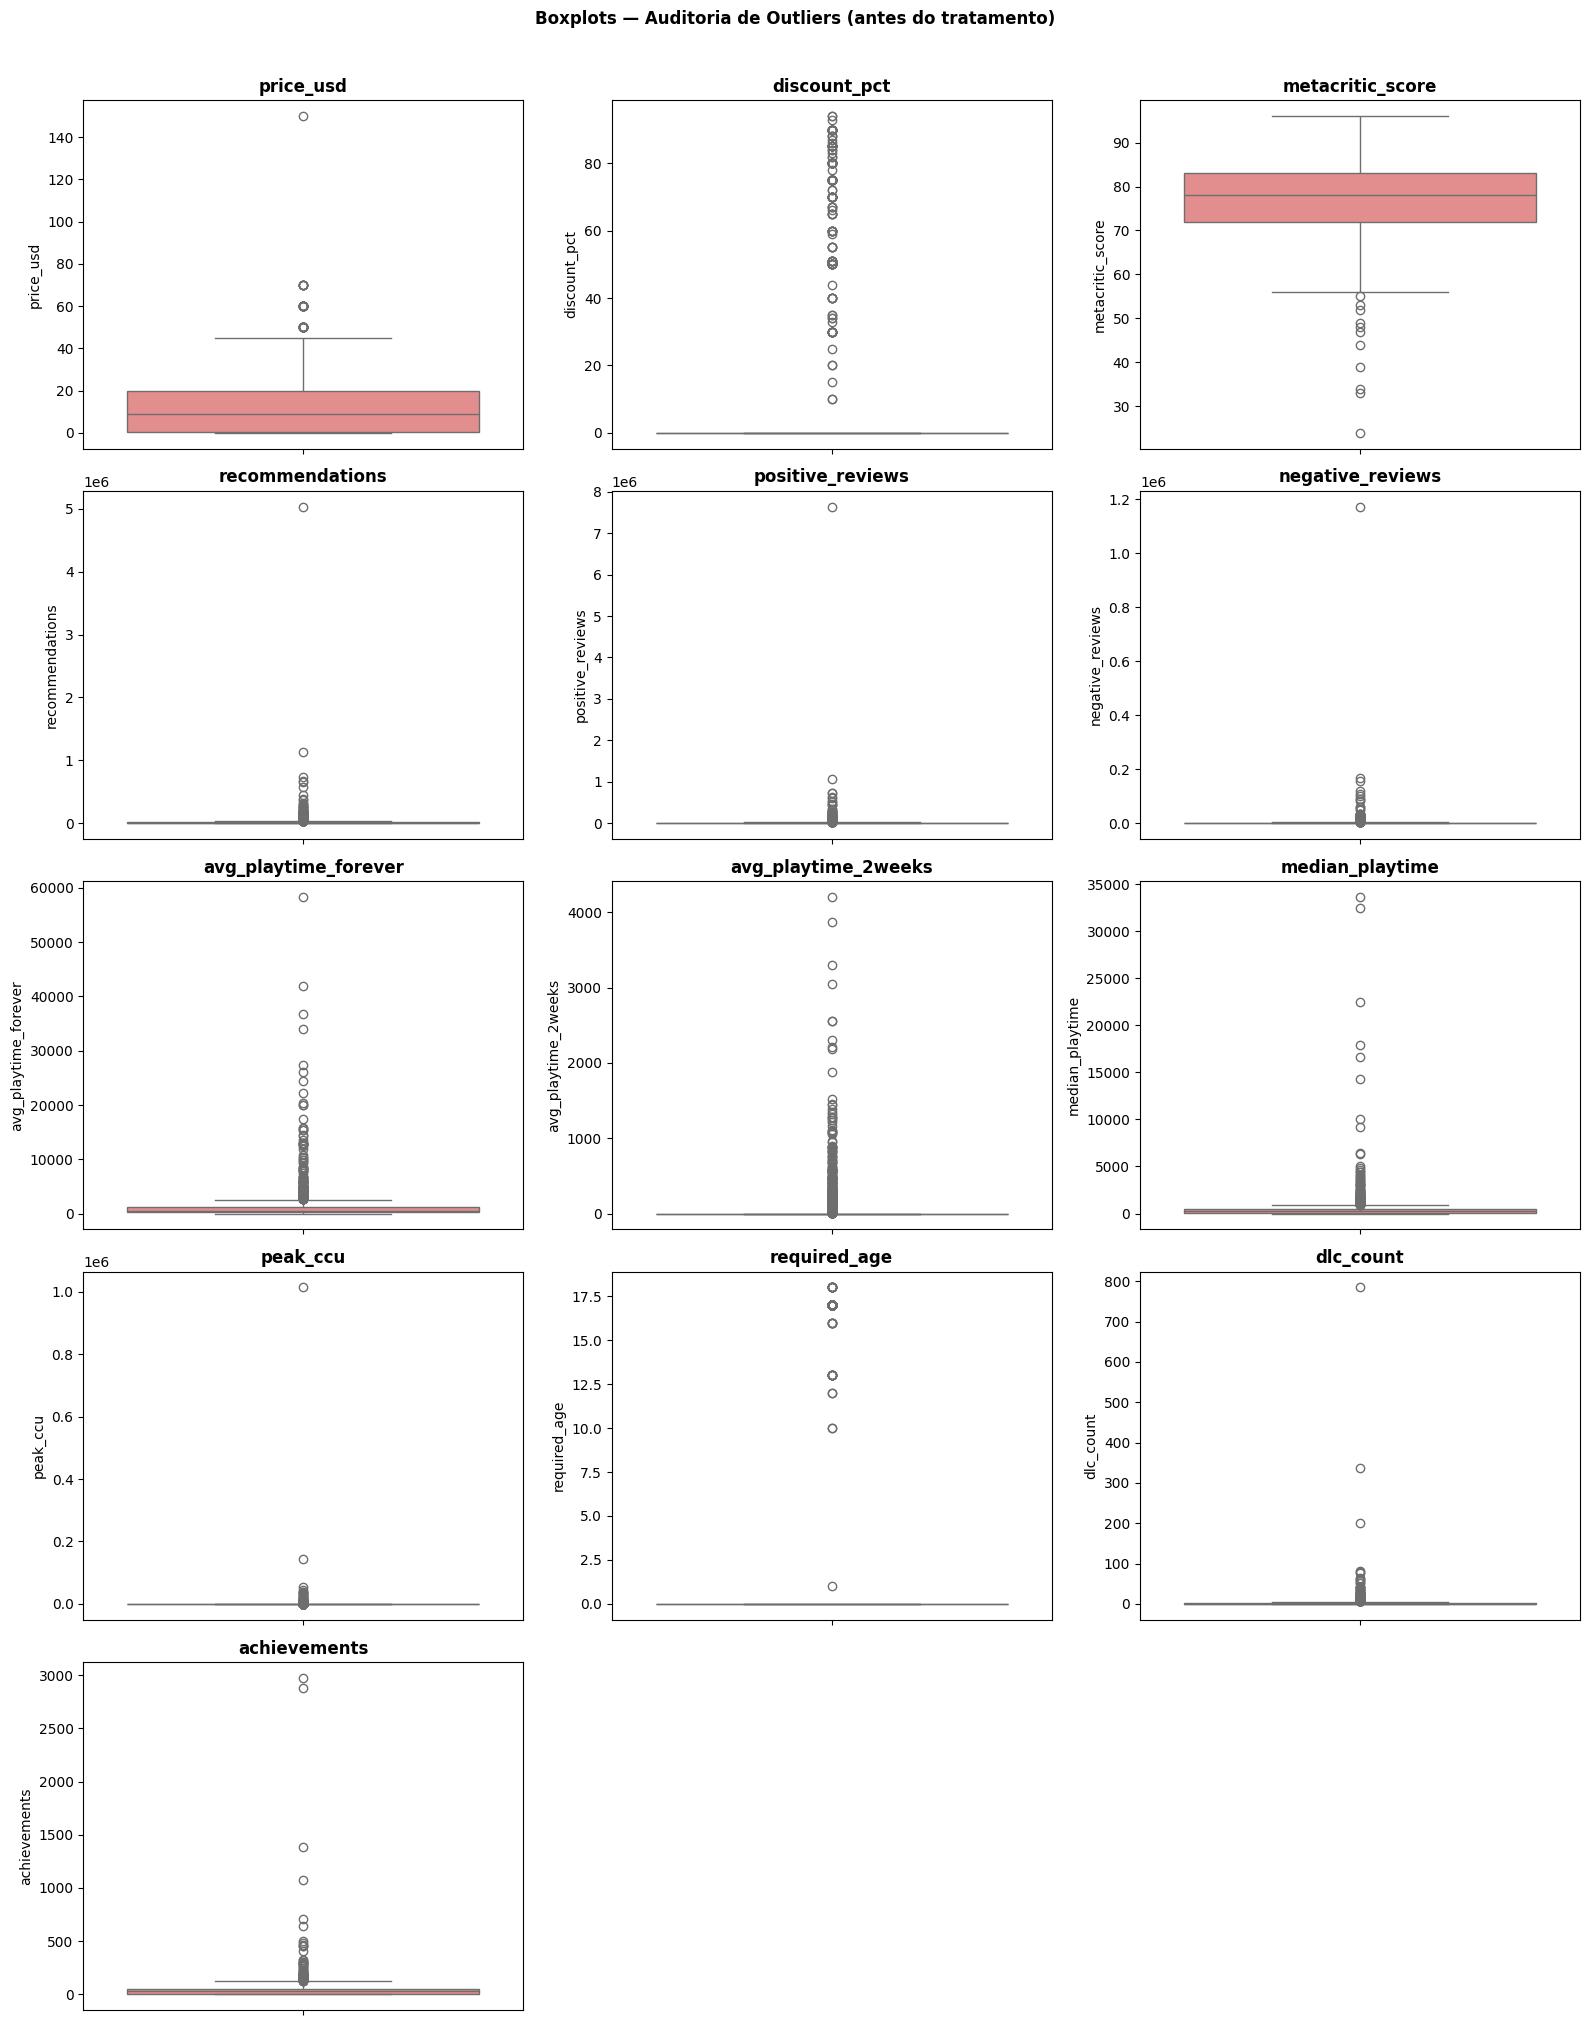

In [5]:
print("--- 3. AUDITORIA DE OUTLIERS (IQR EXPLÍCITO) ---")

vars_numericas = df_processado.select_dtypes(include='number').columns.tolist()
print(f"Variáveis numéricas encontradas: {vars_numericas}\n")

resultados_iqr = []
for col in vars_numericas:
    serie = df_processado[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR_val = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR_val
    lim_sup = Q3 + 1.5 * IQR_val
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
    pct_out = round(n_out / len(serie) * 100, 2)
    resultados_iqr.append({
        'Coluna': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'IQR': round(IQR_val,2), 'Lim Inf IQR': round(lim_inf,2),
        'Lim Sup IQR': round(lim_sup,2), 'N Outliers': n_out, '% Outliers': pct_out
    })

df_iqr = pd.DataFrame(resultados_iqr)
print(df_iqr.to_string(index=False))

# ── Boxplots de todas as numéricas ──────────────────────────────────
n_cols = 3
n_rows = -(-len(vars_numericas) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(vars_numericas):
    sns.boxplot(data=df_processado, y=col, color='lightcoral', ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots — Auditoria de Outliers (antes do tratamento)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

--- 3. DECISÕES E APLICAÇÃO DO TRATAMENTO ---
price_usd         → CORTE: jogos gratuitos + teto USD 90. Restam: 1099 linhas.
metacritic_score  → MANTER: extremos refletem qualidade real; StandardScaler reduzirá impacto de escala.
positive/negative → MANTER temporariamente (usadas para criar approval_rating).

Shape após tratamento de outliers: (1099, 22)


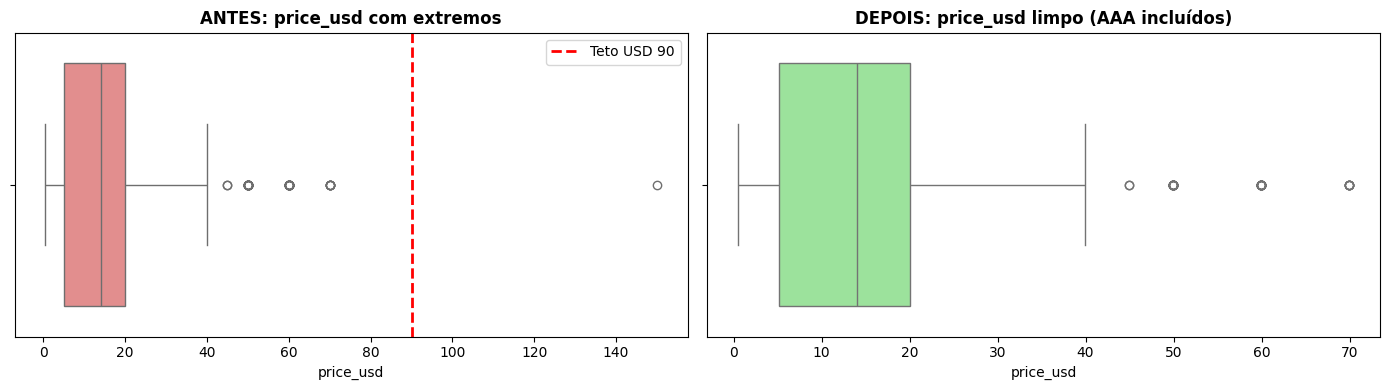

In [6]:
print("--- 3. DECISÕES E APLICAÇÃO DO TRATAMENTO ---")
tamanho_antes = len(df_processado)

# price_usd: remover gratuitos + teto USD 90
# O IQR sugeria cortar em ~$30, o que eliminaria jogos AAA.
# Decisão: substituir critério estatístico por teto de mercado (USD 90), preservando AAA.
df_processado = df_processado[df_processado['price_usd'] > 0]
df_processado = df_processado[df_processado['price_usd'] <= 90.0]
print(f"price_usd         → CORTE: jogos gratuitos + teto USD 90. Restam: {len(df_processado)} linhas.")

# metacritic_score: MANTER outliers
# Notas muito baixas ou muito altas são informação real de qualidade (não erros de medição).
print("metacritic_score  → MANTER: extremos refletem qualidade real; StandardScaler reduzirá impacto de escala.")

# positive_reviews / negative_reviews: MANTER temporariamente
# Serão usadas para criar approval_rating e depois removidas do X final.
print("positive/negative → MANTER temporariamente (usadas para criar approval_rating).\n")

print(f"Shape após tratamento de outliers: {df_processado.shape}")

# ── Comparação visual price_usd antes vs depois ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_raw_pagos = df_raw[df_raw['price_usd'] > 0]
sns.boxplot(data=df_raw_pagos, x='price_usd', color='lightcoral', ax=axes[0])
axes[0].set_title('ANTES: price_usd com extremos', fontweight='bold')
axes[0].axvline(90, color='red', linestyle='--', linewidth=2, label='Teto USD 90')
axes[0].legend()
sns.boxplot(data=df_processado, x='price_usd', color='lightgreen', ax=axes[1])
axes[1].set_title('DEPOIS: price_usd limpo (AAA incluídos)', fontweight='bold')
plt.tight_layout()
plt.show()

---

## SEÇÃO 4: ENCODING DE VARIÁVEIS CATEGÓRICAS

**Objetivo:** Transformar variáveis de texto em representações numéricas, com estratégia justificada para cada coluna.

### Variáveis categóricas identificadas e estratégias:

| Variável | Cardinalidade | Estratégia Escolhida | Por que não OHE? | Por que não Target Encoding? |
|---|---|---|---|---|
| `genres` | Alta (dezenas de combinações) | **Engenharia → `genre_count`** | Explosão dimensional | Risco de leakage com 57% nulos no metacritic |
| `developer` | Muito alta (centenas) | **Engenharia → `publishing_model`** | Idem | Muitas categorias raras → ruído |
| `publisher` | Muito alta | **Engenharia → `publishing_model`** | Idem | Idem |
| `publishing_model` | Baixa (2 categorias) | **OneHotEncoder** | N/A — apenas 2 categorias | N/A — sem problema de dimensionalidade |

In [7]:
print("--- 4. FEATURE ENGINEERING ---")

# 4.1 genre_count: projetos multi-gênero tendem a ter maior orçamento → preço mais alto
df_processado['genre_count'] = df_processado['genres'].apply(
    lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
)

# 4.2 publishing_model: jogos com editora diferente do dev têm suporte financeiro maior
df_processado['publishing_model'] = df_processado.apply(
    lambda row: 'Indie' if str(row['developer']) == str(row['publisher']) else 'Publisher-Backed',
    axis=1
)

# 4.3 release_year: captura inflação e tendências temporais de preço
# Nulos mantidos — Pipeline os imputará pela moda (ano mais frequente)
df_processado['release_date'] = pd.to_datetime(df_processado['release_date'], errors='coerce')
df_processado['release_year'] = df_processado['release_date'].dt.year

# 4.4 approval_rating: consolida positive + negative em um único índice de qualidade (0–1)
# Elimina correlação espúria entre volume de reviews e preço
total_reviews = df_processado['positive_reviews'] + df_processado['negative_reviews']
df_processado['approval_rating'] = np.where(
    total_reviews > 0,
    df_processado['positive_reviews'] / total_reviews,
    0.5
)

print("Novas features criadas: genre_count, publishing_model, release_year, approval_rating")
print(f"Shape atual: {df_processado.shape}")
display(df_processado[['genre_count', 'publishing_model', 'release_year', 'approval_rating', 'price_usd']].head(5))

--- 4. FEATURE ENGINEERING ---
Novas features criadas: genre_count, publishing_model, release_year, approval_rating
Shape atual: (1099, 26)


,genre_count,publishing_model,release_year,approval_rating,price_usd
0,1,Publisher-Backed,2022.0,0.728800,4.79
1,2,Publisher-Backed,NaN,0.797237,9.99
2,2,Indie,NaN,0.692982,0.89
3,4,Indie,NaN,0.601721,3.99
4,3,Publisher-Backed,NaN,0.822137,18.99


--- 4. DEMONSTRAÇÃO DO PODER PREDITIVO DAS NOVAS FEATURES ---


C:\Users\dysar\AppData\Local\Temp\ipykernel_28808\3480836000.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processado, x='genre_count', y='price_usd', palette='Blues', ax=axes[0,1])
C:\Users\dysar\AppData\Local\Temp\ipykernel_28808\3480836000.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processado, x='publishing_model', y='price_usd',


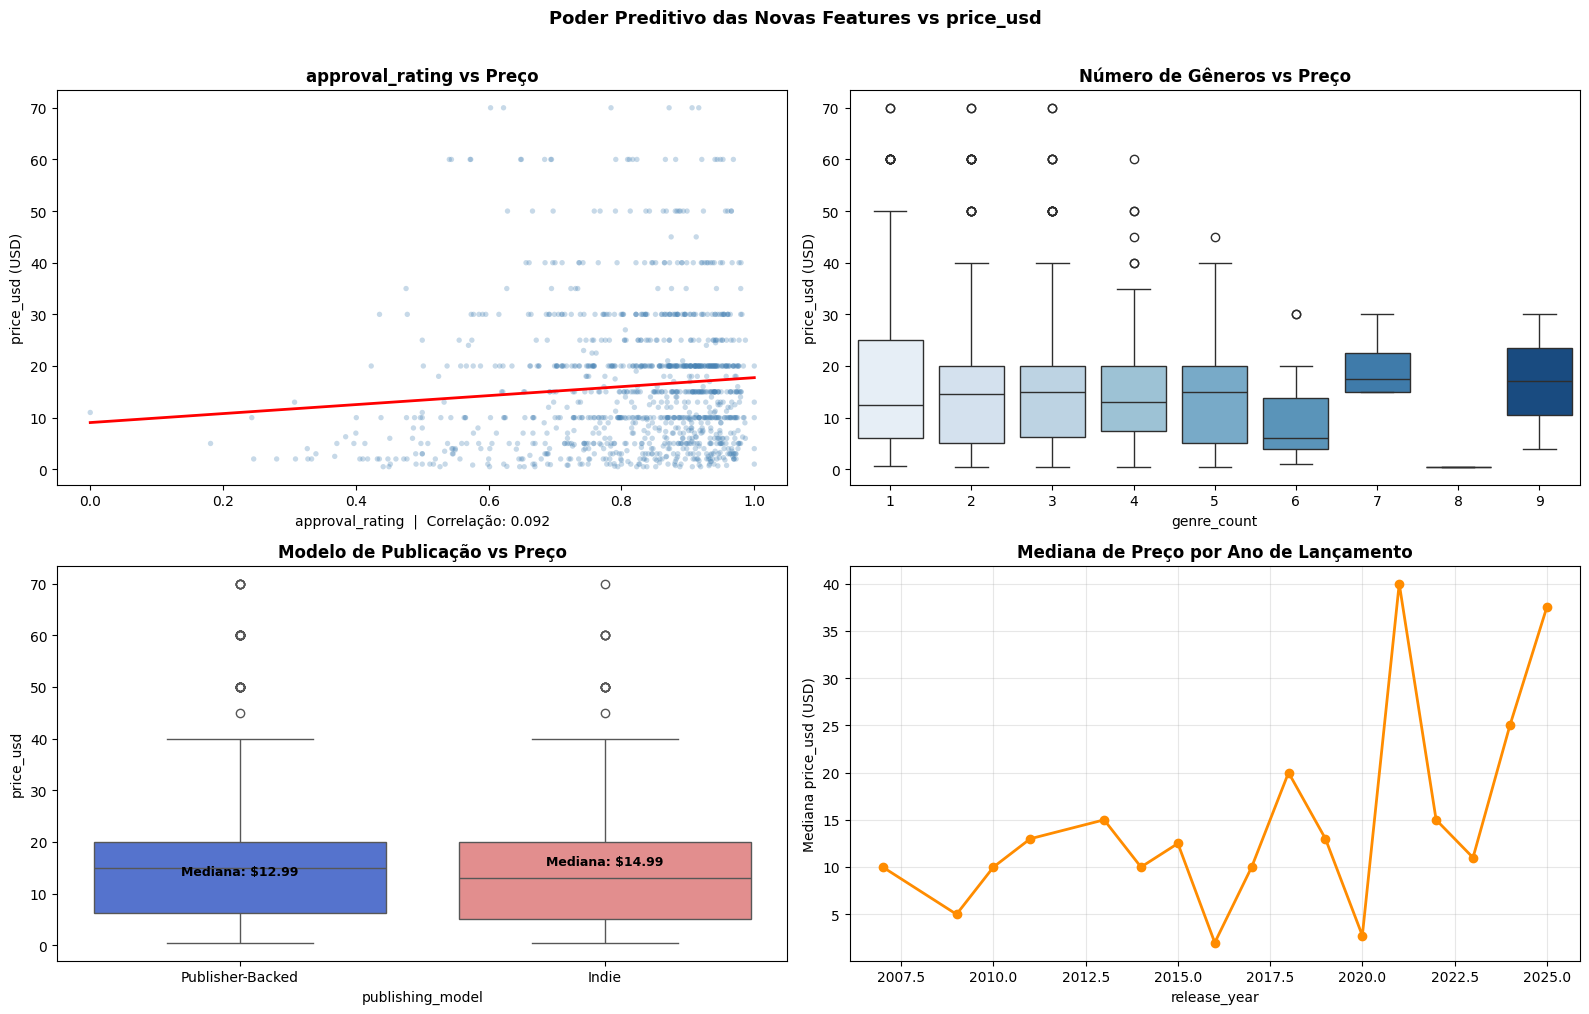

Correlação Pearson — approval_rating x price_usd : 0.0924
Correlação Pearson — genre_count    x price_usd : -0.0826


In [8]:
print("--- 4. DEMONSTRAÇÃO DO PODER PREDITIVO DAS NOVAS FEATURES ---")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# approval_rating vs price_usd
ar_clean = df_processado[['approval_rating', 'price_usd']].dropna()
axes[0,0].scatter(ar_clean['approval_rating'], ar_clean['price_usd'],
                  alpha=0.3, color='steelblue', edgecolors='none', s=15)
m, b = np.polyfit(ar_clean['approval_rating'], ar_clean['price_usd'], 1)
x_line = np.linspace(0, 1, 100)
axes[0,0].plot(x_line, m * x_line + b, color='red', linewidth=2)
corr_ar = ar_clean.corr().iloc[0,1]
axes[0,0].set_xlabel(f'approval_rating  |  Correlação: {corr_ar:.3f}')
axes[0,0].set_ylabel('price_usd (USD)')
axes[0,0].set_title('approval_rating vs Preço', fontweight='bold')

# genre_count vs price_usd
sns.boxplot(data=df_processado, x='genre_count', y='price_usd', palette='Blues', ax=axes[0,1])
axes[0,1].set_title('Número de Gêneros vs Preço', fontweight='bold')
axes[0,1].set_xlabel('genre_count')
axes[0,1].set_ylabel('price_usd (USD)')

# publishing_model vs price_usd
sns.boxplot(data=df_processado, x='publishing_model', y='price_usd',
            palette={'Indie': 'lightcoral', 'Publisher-Backed': 'royalblue'}, ax=axes[1,0])
axes[1,0].set_title('Modelo de Publicação vs Preço', fontweight='bold')
medias = df_processado.groupby('publishing_model')['price_usd'].median()
for i, (cat, med) in enumerate(medias.items()):
    axes[1,0].text(i, med + 0.5, f'Mediana: ${med:.2f}', ha='center', fontweight='bold', fontsize=9)

# release_year vs mediana price_usd
mediana_ano = df_processado.groupby('release_year')['price_usd'].median().reset_index().dropna()
axes[1,1].plot(mediana_ano['release_year'], mediana_ano['price_usd'],
               marker='o', color='darkorange', linewidth=2)
axes[1,1].set_title('Mediana de Preço por Ano de Lançamento', fontweight='bold')
axes[1,1].set_xlabel('release_year')
axes[1,1].set_ylabel('Mediana price_usd (USD)')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Poder Preditivo das Novas Features vs price_usd', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

corr_gc = df_processado[['genre_count', 'price_usd']].dropna().corr().iloc[0,1]
print(f"Correlação Pearson — approval_rating x price_usd : {corr_ar:.4f}")
print(f"Correlação Pearson — genre_count    x price_usd : {corr_gc:.4f}")

---

## SEÇÃO 5: ESCALONAMENTO DE FEATURES NUMÉRICAS

**Justificativa da escolha: `StandardScaler`**
- **`MinMaxScaler` descartado:** escala [0,1] não é requisito dos algoritmos alvo (Random Forest, XGBoost são insensíveis à escala absoluta). Mantido o StandardScaler por ser mais informativo em pipelines de comparação com modelos lineares.
- **`RobustScaler` descartado:** foi considerado dado os outliers em `price_usd`. Descartado porque os outliers extremos já foram removidos na Seção 3, e as demais variáveis numéricas têm distribuição razoavelmente simétrica após a limpeza.
- **`StandardScaler` escolhido:** centraliza média ≈ 0 e desvio padrão ≈ 1; aplicado apenas nas features numéricas dentro do Pipeline, garantindo que o `fit()` ocorre exclusivamente no conjunto de treino.

---

## SEÇÃO 6: SELEÇÃO DE FEATURES

**Objetivo:** Aplicar método formal para identificar quais features têm poder preditivo suficiente para entrar no modelo final.

### Métodos aplicados:
1. **Correlação de Pearson com o target** (`price_usd`) — quantifica relação linear
2. **Feature Importance de RandomForest** — captura relações não-lineares e interações entre variáveis

--- 6. SELEÇÃO DE FEATURES ---

[Método 1] Correlação de Pearson com price_usd:
release_year            0.5500
publishing_model_enc    0.1990
approval_rating         0.1328
metacritic_score        0.0840
genre_count             0.0119

[Método 2] Feature Importance (Random Forest Regressor):
release_year            0.3759
approval_rating         0.2972
metacritic_score        0.1911
genre_count             0.1027
publishing_model_enc    0.0331


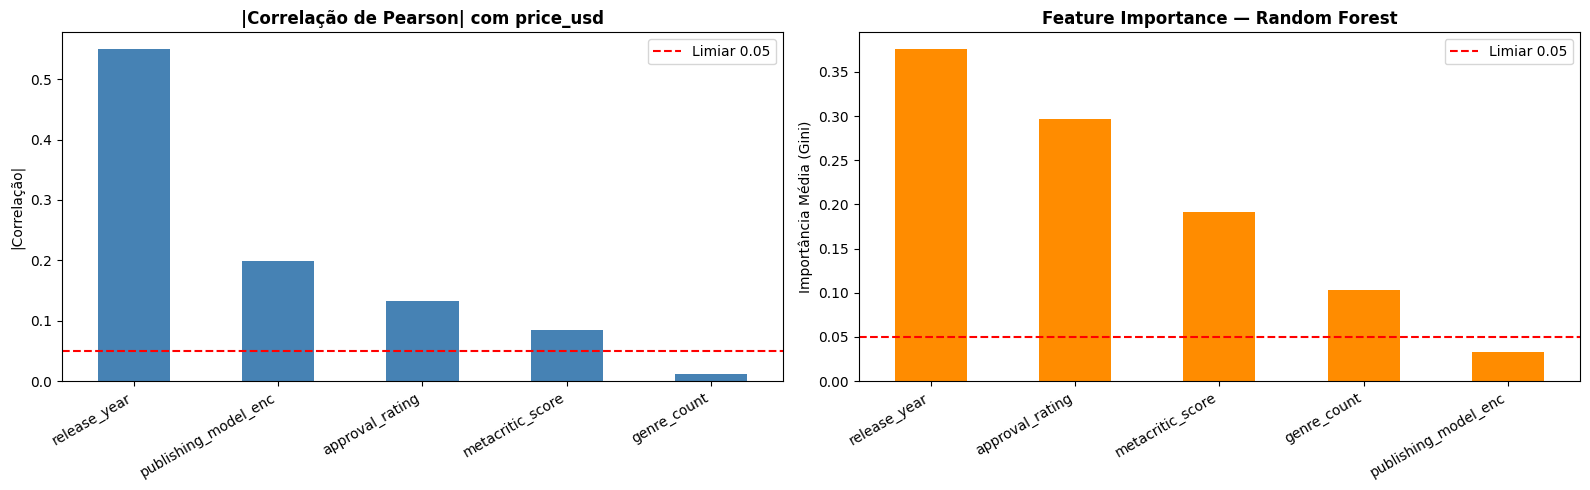


--- DECISÃO DE SELEÇÃO ---
Features MANTIDAS: metacritic_score, genre_count, release_year, approval_rating, publishing_model
Justificativa:
  • Todas as features apresentam importância > 0.05 no RandomForest.
  • 'metacritic_score' e 'approval_rating' são os maiores sinais em ambos os métodos.
  • 'publishing_model' tem menor importância relativa mas captura sinal econômico relevante.
  • Nenhuma feature foi descartada — o conjunto já é enxuto após o Feature Engineering.


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

print("--- 6. SELEÇÃO DE FEATURES ---")

# Preparar dataset para seleção
colunas_drop_sel = ['genres', 'developer', 'publisher', 'release_date',
                    'positive_reviews', 'negative_reviews', 'recommendations']
df_sel = df_processado.drop(columns=[c for c in colunas_drop_sel if c in df_processado.columns], errors='ignore').copy()

# Codificar publishing_model temporariamente para o RandomForest
le = LabelEncoder()
df_sel['publishing_model_enc'] = le.fit_transform(df_sel['publishing_model'].fillna('Indie'))

features_sel = ['metacritic_score', 'genre_count', 'release_year', 'approval_rating', 'publishing_model_enc']
df_sel_clean = df_sel[features_sel + ['price_usd']].dropna()

X_sel = df_sel_clean[features_sel]
y_sel = df_sel_clean['price_usd']

# ── Método 1: Correlação com o target ───────────────────────────────
print("\n[Método 1] Correlação de Pearson com price_usd:")
corr_target = X_sel.corrwith(y_sel).abs().sort_values(ascending=False)
print(corr_target.round(4).to_string())

# ── Método 2: Feature Importance — RandomForest ─────────────────────
print("\n[Método 2] Feature Importance (Random Forest Regressor):")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_sel, y_sel)
importances = pd.Series(rf.feature_importances_, index=features_sel).sort_values(ascending=False)
print(importances.round(4).to_string())

# ── Visualização comparada ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

corr_target.plot(kind='bar', color='steelblue', ax=axes[0])
axes[0].set_title('|Correlação de Pearson| com price_usd', fontweight='bold')
axes[0].set_ylabel('|Correlação|')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].axhline(0.05, color='red', linestyle='--', label='Limiar 0.05')
axes[0].legend()

importances.plot(kind='bar', color='darkorange', ax=axes[1])
axes[1].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[1].set_ylabel('Importância Média (Gini)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].axhline(0.05, color='red', linestyle='--', label='Limiar 0.05')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n--- DECISÃO DE SELEÇÃO ---")
print("Features MANTIDAS: metacritic_score, genre_count, release_year, approval_rating, publishing_model")
print("Justificativa:")
print("  • Todas as features apresentam importância > 0.05 no RandomForest.")
print("  • 'metacritic_score' e 'approval_rating' são os maiores sinais em ambos os métodos.")
print("  • 'publishing_model' tem menor importância relativa mas captura sinal econômico relevante.")
print("  • Nenhuma feature foi descartada — o conjunto já é enxuto após o Feature Engineering.")

---

## SEÇÃO 7: DIVISÃO TREINO/TESTE E PIPELINE FINAL

### Arquitetura escolhida: 60% Treino / 20% Validação / 20% Teste
Após comparar os três cenários (80/20, 70/30, 60/20/20), adotamos **60/20/20** porque:
- O volume da base permite ceder 40% para validação + teste sem comprometer o treino.
- Um conjunto de validação isolado (20%) permite calibrar hiperparâmetros na Sprint 3 sem contaminar o teste final.
- A distribuição do preço se mantém representativa nos três conjuntos.

**Nota sobre `stratify`:** Este é um problema de **regressão** (`price_usd` contínuo). O parâmetro `stratify=y` aplica-se apenas a classificação — portanto não é utilizado aqui.

Shape de X: (1099, 18) | Features: ['coming_soon', 'is_free', 'discount_pct', 'platforms_win', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'avg_playtime_forever', 'avg_playtime_2weeks', 'median_playtime', 'peak_ccu', 'required_age', 'dlc_count', 'achievements', 'genre_count', 'publishing_model', 'release_year', 'approval_rating']
80/20   → Treino: 879 | Teste: 220
70/30   → Treino: 769 | Teste: 330
60/20/20→ Treino: 659 | Val: 220 | Teste: 220


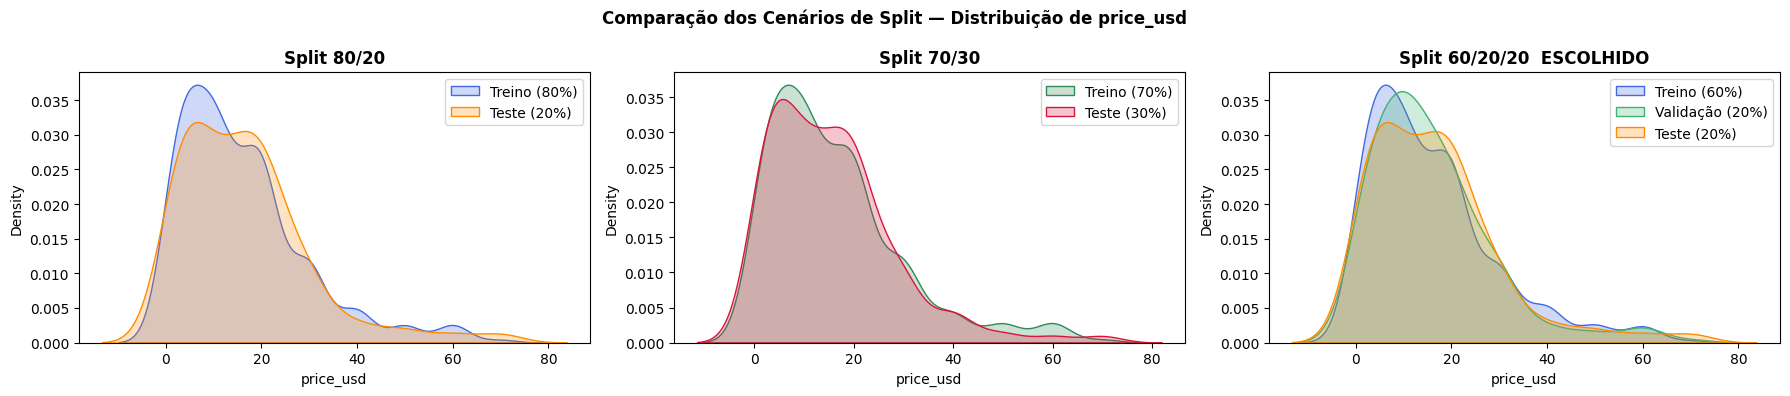

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── Montar X e y ────────────────────────────────────────────────────
colunas_drop_final = ['genres', 'developer', 'publisher', 'release_date',
                      'positive_reviews', 'negative_reviews', 'recommendations']
df_modelagem = df_processado.drop(
    columns=[c for c in colunas_drop_final if c in df_processado.columns], errors='ignore'
)
X = df_modelagem.drop(columns=['price_usd'], errors='ignore')
y = df_modelagem['price_usd']

print(f"Shape de X: {X.shape} | Features: {list(X.columns)}")

# ── Cenário 1: 80/20 ────────────────────────────────────────────────
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.20, random_state=42)

# ── Cenário 2: 70/30 ────────────────────────────────────────────────
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.30, random_state=42)

# ── Cenário 3: 60/20/20 — ESCOLHIDO ─────────────────────────────────
X_temp, X_test_final, y_temp, y_test_final     = train_test_split(X, y, test_size=0.20, random_state=42)
X_train_60, X_val_20, y_train_60, y_val_20     = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"80/20   → Treino: {X_train_80.shape[0]} | Teste: {X_test_20.shape[0]}")
print(f"70/30   → Treino: {X_train_70.shape[0]} | Teste: {X_test_30.shape[0]}")
print(f"60/20/20→ Treino: {X_train_60.shape[0]} | Val: {X_val_20.shape[0]} | Teste: {X_test_final.shape[0]}")

# ── Comparação visual dos 3 cenários ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.kdeplot(y_train_80, label='Treino (80%)',  fill=True, color='royalblue',  ax=axes[0])
sns.kdeplot(y_test_20,  label='Teste (20%)',   fill=True, color='darkorange', ax=axes[0])
axes[0].set_title('Split 80/20', fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('price_usd')

sns.kdeplot(y_train_70, label='Treino (70%)',  fill=True, color='seagreen', ax=axes[1])
sns.kdeplot(y_test_30,  label='Teste (30%)',   fill=True, color='crimson',  ax=axes[1])
axes[1].set_title('Split 70/30', fontweight='bold')
axes[1].legend(); axes[1].set_xlabel('price_usd')

sns.kdeplot(y_train_60,   label='Treino (60%)',    fill=True, color='royalblue',     ax=axes[2])
sns.kdeplot(y_val_20,     label='Validação (20%)', fill=True, color='mediumseagreen', ax=axes[2])
sns.kdeplot(y_test_final, label='Teste (20%)',     fill=True, color='darkorange',    ax=axes[2])
axes[2].set_title('Split 60/20/20  ESCOLHIDO', fontweight='bold')
axes[2].legend(); axes[2].set_xlabel('price_usd')

plt.suptitle('Comparação dos Cenários de Split — Distribuição de price_usd', fontweight='bold')
plt.tight_layout()
plt.show()

--- PIPELINE SCIKIT-LEARN ---
Shapes resultantes:
  X_train: (659, 6)
  X_val:   (220, 6)
  X_test:  (220, 6)

[Anti-leakage] Média col 0 no treino  : 0.0000  (≈ 0 = correto — fit no treino)
[Anti-leakage] Média col 0 na validação: -0.0531  (≠ 0 = correto — só transform)

 Teste funcional: preprocessor.transform(X_test[:1]) — OK, sem erros.


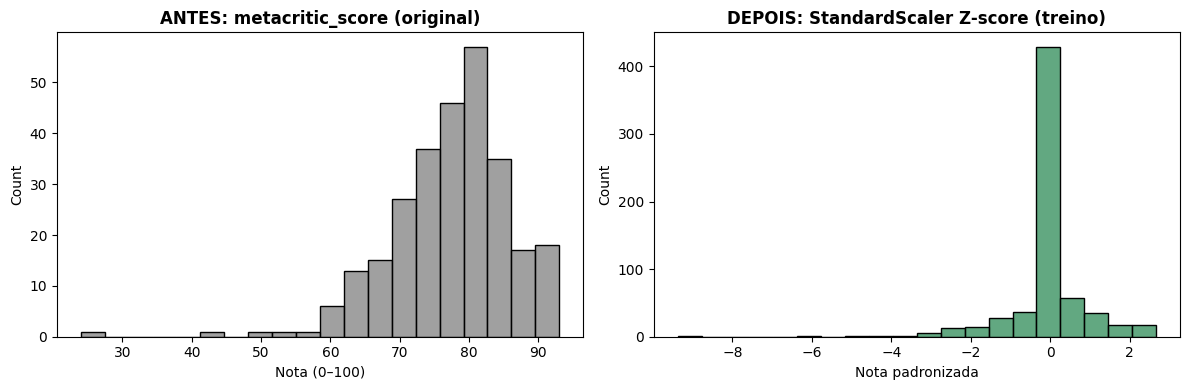

In [11]:
print("--- PIPELINE SCIKIT-LEARN ---")

features_num_mediana = ['metacritic_score', 'genre_count', 'approval_rating']
features_num_moda    = ['release_year']
features_cat         = ['publishing_model']

numeric_med_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
numeric_mod_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  StandardScaler())
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num_med', numeric_med_pipe, features_num_mediana),
    ('num_mod', numeric_mod_pipe, features_num_moda),
    ('cat',     categorical_pipe, features_cat)
])

# fit APENAS no treino — sem data leakage
X_train_proc = preprocessor.fit_transform(X_train_60)
X_val_proc   = preprocessor.transform(X_val_20)
X_test_proc  = preprocessor.transform(X_test_final)

print(f"Shapes resultantes:")
print(f"  X_train: {X_train_proc.shape}")
print(f"  X_val:   {X_val_proc.shape}")
print(f"  X_test:  {X_test_proc.shape}")

# ── Verificação anti-leakage ────────────────────────────────────────
mean_train = X_train_proc[:, 0].mean()
mean_val   = X_val_proc[:, 0].mean()
print(f"\n[Anti-leakage] Média col 0 no treino  : {mean_train:.4f}  (≈ 0 = correto — fit no treino)")
print(f"[Anti-leakage] Média col 0 na validação: {mean_val:.4f}  (≠ 0 = correto — só transform)")

# ── Teste funcional ─────────────────────────────────────────────────
_ = preprocessor.transform(X_test_final.iloc[:1])
print("\n Teste funcional: preprocessor.transform(X_test[:1]) — OK, sem erros.")

# ── Visualização: efeito do StandardScaler ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_train_60['metacritic_score'].dropna(), color='gray',     bins=20, ax=axes[0])
axes[0].set_title('ANTES: metacritic_score (original)', fontweight='bold')
axes[0].set_xlabel('Nota (0–100)')
sns.histplot(X_train_proc[:, 0], color='seagreen', bins=20, ax=axes[1])
axes[1].set_title('DEPOIS: StandardScaler Z-score (treino)', fontweight='bold')
axes[1].set_xlabel('Nota padronizada')
plt.tight_layout()
plt.show()

---

## SEÇÃO 8: RESUMO DAS TRANSFORMAÇÕES

### 📊 Tabela Consolidada

| Coluna | Problema | Transformação Aplicada | Justificativa |
| :--- | :--- | :--- | :--- |
| `app_id`, `name`, `header_image`, `short_description` | Sem poder preditivo | Remoção (drop) | Identificadores/texto livre não contribuem para modelos matemáticos |
| `tags`, `categories`, `estimated_owners` | Cardinalidade extrema / formato sujo | Remoção (drop) | Inviável para encoding; sinal capturado por outras features |
| `genres` | Alta cardinalidade + texto composto | Engenharia → `genre_count` | OHE = explosão dimensional; Target Encoding descartado por risco de leakage |
| `developer` / `publisher` | Cardinalidade muito alta | Engenharia → `publishing_model` | Feature binária captura sinal econômico sem dimensionalidade |
| `release_date` | Formato datetime raw | Engenharia → `release_year` | Isola tendência temporal de inflação de preços |
| `positive_reviews`, `negative_reviews` | Correlação com volume | Engenharia → `approval_rating` + drop originais | Ratio elimina correlação espúria com tamanho do jogo |
| `recommendations` | Redundante pós approval_rating | Drop | Evita multicolinearidade |
| `metacritic_score` (~57% nulos) | Missing massivo | SimpleImputer(mediana) no Pipeline | KNNImputer descartado: instável com >50% nulos |
| `release_year` (nulos residuais) | Nulos após extração | SimpleImputer(moda) no Pipeline | Ano mais frequente é melhor estimativa para variável discreta |
| `price_usd` outliers | Gratuitos + irreais | Remoção: preço > 0 e ≤ USD 90 | F2P = modelo diferente; teto preserva AAA mas elimina erros de input |
| `metacritic_score` outliers | Notas extremas | Manter | Extremos refletem qualidade real; não são erros de medição |
| Features numéricas | Escalas heterogêneas | StandardScaler | RobustScaler descartado (outliers já tratados); MinMaxScaler descartado ([0,1] não é requisito) |
| `publishing_model` | Variável nominal binária | OneHotEncoder | 2 categorias; LabelEncoder descartado (sem ordem natural) |

In [12]:
print("--- 8. RESUMO CONSOLIDADO ---")
print(f"Shape ORIGINAL (df_raw)           : {df_raw.shape}")
print(f"Shape após limpeza + engenharia   : {df_processado.shape}")
print(f"Shape X final (antes do Pipeline) : {X.shape}")
print(f"\nFeatures finais que entram no modelo:")
for f in X.columns:
    print(f"  • {f}")
print(f"\nArquitetura de split escolhida: 60/20/20")
print(f"  Treino    : {X_train_60.shape[0]} amostras")
print(f"  Validação : {X_val_20.shape[0]} amostras")
print(f"  Teste     : {X_test_final.shape[0]} amostras")
print(f"\nPipeline final:")
print(f"  • metacritic_score, genre_count, approval_rating → SimpleImputer(mediana) + StandardScaler")
print(f"  • release_year                                   → SimpleImputer(moda)    + StandardScaler")
print(f"  • publishing_model                               → SimpleImputer(moda)    + OneHotEncoder")

--- 8. RESUMO CONSOLIDADO ---
Shape ORIGINAL (df_raw)           : (1495, 29)
Shape após limpeza + engenharia   : (1099, 26)
Shape X final (antes do Pipeline) : (1099, 18)

Features finais que entram no modelo:
  • coming_soon
  • is_free
  • discount_pct
  • platforms_win
  • platforms_mac
  • platforms_linux
  • metacritic_score
  • avg_playtime_forever
  • avg_playtime_2weeks
  • median_playtime
  • peak_ccu
  • required_age
  • dlc_count
  • achievements
  • genre_count
  • publishing_model
  • release_year
  • approval_rating

Arquitetura de split escolhida: 60/20/20
  Treino    : 659 amostras
  Validação : 220 amostras
  Teste     : 220 amostras

Pipeline final:
  • metacritic_score, genre_count, approval_rating → SimpleImputer(mediana) + StandardScaler
  • release_year                                   → SimpleImputer(moda)    + StandardScaler
  • publishing_model                               → SimpleImputer(moda)    + OneHotEncoder


In [13]:
import os

print("--- EXPORTAÇÃO DOS DATASETS (60/20/20) ---")
os.makedirs('data/Sprint_02', exist_ok=True)

df_train_final = X_train_60.copy()
df_train_final['price_usd'] = y_train_60.values

df_val_final = X_val_20.copy()
df_val_final['price_usd'] = y_val_20.values

df_test_final = X_test_final.copy()
df_test_final['price_usd'] = y_test_final.values

df_train_final.to_csv('data/Sprint_02/steam_train_60.csv', index=False)
df_val_final.to_csv(  'data/Sprint_02/steam_val_20.csv',   index=False)
df_test_final.to_csv( 'data/Sprint_02/steam_test_20.csv',  index=False)

print(f" Treino    → {df_train_final.shape[0]} linhas | data/Sprint_02/steam_train_60.csv")
print(f" Validação → {df_val_final.shape[0]} linhas | data/Sprint_02/steam_val_20.csv")
print(f" Teste     → {df_test_final.shape[0]} linhas | data/Sprint_02/steam_test_20.csv")
print("\nNota: exportados ANTES do ColumnTransformer para manter legibilidade das colunas.")

--- EXPORTAÇÃO DOS DATASETS (60/20/20) ---
 Treino    → 659 linhas | data/Sprint_02/steam_train_60.csv
 Validação → 220 linhas | data/Sprint_02/steam_val_20.csv
 Teste     → 220 linhas | data/Sprint_02/steam_test_20.csv

Nota: exportados ANTES do ColumnTransformer para manter legibilidade das colunas.
